In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy
import os

from osiris_filename import make_osiris_filename
from osiris_h5data_obj import get_cylindrical_data

In [2]:
import os

os.chdir('/home/stsoukalas/Plasma_PINNS/mode_decomposition/')

from gabi_decomp import *
from alfven_decomp import *

In [3]:
data_dir = '/home/stsoukalas/Plasma_PINNS/mode_decomposition/osiris_data_interp/' # or wherever you put the MS directory

In [4]:
ndump = 50 # frequency of diagnostic dumps in OSIRIS simulation

last_dump_num = int(sorted(os.listdir(data_dir +'/MS/FLD/MODE-0-RE/b1_cyl_m/'))[-1][-9:][:-3])
print(last_dump_num)

last_dump_simulation_idx = ndump * last_dump_num
print(last_dump_simulation_idx)

307
15350


### Get grid parameters from OSIRIS file + get field data

In [5]:
# The grid parameters are stored as attributes for every data object created by the output hdf5 files
# Therefore, all we need to do is load in a data object for the very first dumped output 
# This can be achieved by loading in the data for any field (let's use Bz), and any mode (let's use m = 0 Real)

filename = make_osiris_filename(
    'b1', last_dump_num, data_type='field', cylindrical=True,
    mode_type='re', folder=data_dir, mode=0
)

print(filename)

# This object has all the attributes we will need
# See osiris_h5data_obj.py for reference
data_obj = get_cylindrical_data(filename)

/home/stsoukalas/Plasma_PINNS/mode_decomposition/osiris_data_interp/MS/FLD/MODE-0-RE/b1_cyl_m/b1_cyl_m-0-re-000307.h5


In [6]:
dz = data_obj.DX
dr = data_obj.DY
dt = data_obj.DT[0]

nz = data_obj.NX
nr = data_obj.NY

z_grid = np.linspace(data_obj.AXIS1[0], data_obj.AXIS1[1], nz) # create linspaced 1D z-array
r_grid = np.linspace(data_obj.AXIS2[0], data_obj.AXIS2[1], nr) # create linspaced 1D z-array
t_sim = last_dump_simulation_idx * dt

# Z goes from 0 to z_max, R goes from -dr / 2 to r_max - dr / 2
print(f"dz = {dz:.3f} c / omega_pe")
print(f"dr = {dr:.3f} c / omega_pe")
print(f"dt = {dt:.3f} omega_pe^-1")
print(f"Z array endpoints: ({z_grid[0]:.3f}, {z_grid[-1]:.3f}) c / omega_pe") # zmax in the simulation was 233.33 c / omega_{pe}
print(f"R array endpoints: ({r_grid[0]:.3f}, {r_grid[-1]:.3f}) c / omega_pe") # rmax in the simulation was 120.00 c / omega_{pe}
print(f"Simulation time: {t_sim:.3f} omega_pe^-1") # time of this snapshot in omega_{pe}^{-1}

dz = 0.233 c / omega_pe
dr = 0.200 c / omega_pe
dt = 0.130 omega_pe^-1
Z array endpoints: (0.000, 233.330) c / omega_pe
R array endpoints: (-0.100, 119.900) c / omega_pe
Simulation time: 1995.500 omega_pe^-1


In [7]:
quantity = ['b1', 'b2', 'b3', 'e1', 'e2', 'e3', 'j1', 'j2', 'j3'] # -> 1 = z, 2 = r, 3 = phi
modes = [(0, 're'), (1, 're'), (1, 'im')]
data_dict = {quantity: {mode: np.zeros((nr, nz)) for mode in modes} for quantity in quantity}

for quantity in quantity:
    for mode_tuple in modes:

        data_type = 'field'
        particle  = None

        filename = make_osiris_filename(
            data_name=quantity,
            timestep=last_dump_num, 
            data_type=data_type, 
            folder=data_dir, 
            particle=particle,
            cylindrical=True,
            mode=mode_tuple[0],
            mode_type=mode_tuple[1], 
        )

        data_obj = get_cylindrical_data(filename)

        data_dict[quantity][mode_tuple] = data_obj.DATA # shape: (nr, nz)

### Visualize a few quantities

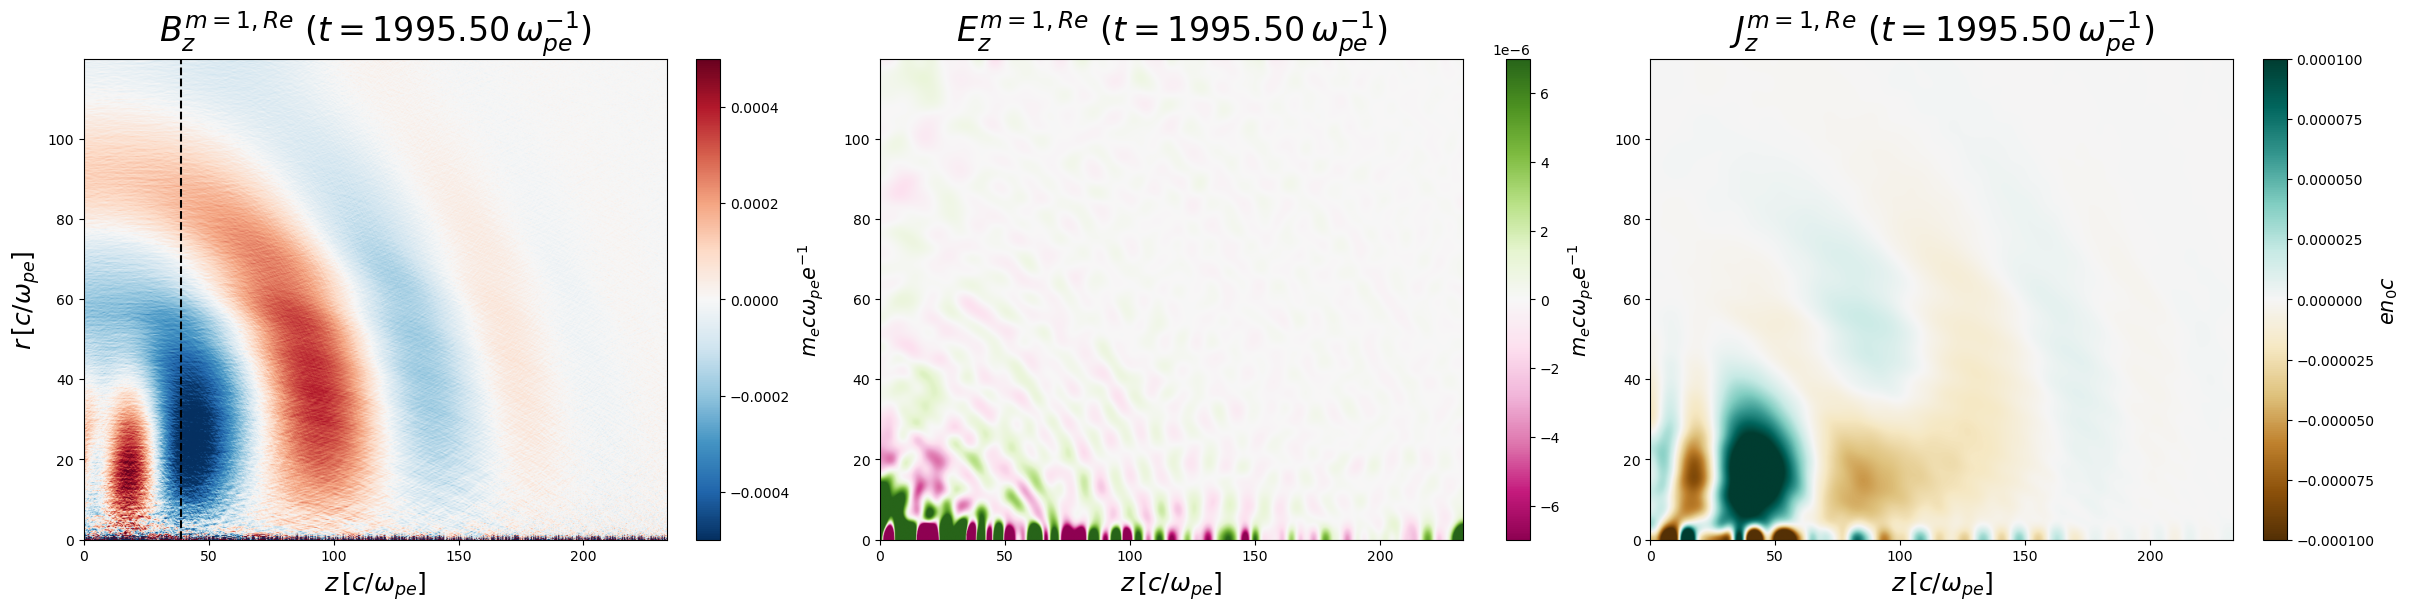

In [12]:
# Viszualize Bz, Ez, Jz for m = 1 Real 

Bz_data = data_dict['b1'][(1, 're')][1:,:] # only visualize above r = 0. You will also want to do this when interpolating modes
Ez_data = data_dict['e1'][(1, 're')][1:,:]
Jz_data = data_dict['j1'][(1, 're')][1:,:]

# Filter Ez and Jz data because they are very noisy
Ez_data = scipy.ndimage.gaussian_filter(Ez_data, sigma=10.0)
Jz_data = scipy.ndimage.gaussian_filter(Jz_data, sigma=10.0)

extent = [z_grid[0], z_grid[-1], r_grid[0], r_grid[-1]]

plt.figure(figsize=(24, 6), constrained_layout=True)

plt.subplot(1,3,1)
plt.title(r'$B_z^{m=1, Re} \, \, (t = $' + f"{t_sim:.2f}" + r'$ \, \omega_{pe}^{-1})$', fontsize=24) 
plt.xlabel(r'$z \, [c / \omega_{pe}]$', fontsize=18)
plt.ylabel(r'$r \, [c / \omega_{pe}]$', fontsize=18)
plt.imshow(Bz_data, aspect='auto', origin='lower', extent=extent, cmap='RdBu_r', vmin=-5e-4, vmax=5e-4)
plt.vlines(z_grid[len(z_grid) // 6], ymin=r_grid[1], ymax=r_grid[-1], linestyle='dashed', color='k')
cbar = plt.colorbar()
cbar.set_label(r'$m_e c \omega_{pe} e^{-1}$', fontsize=15)

plt.subplot(1,3,2)
plt.title(r'$E_z^{m=1, Re} \, \, (t = $' + f"{t_sim:.2f}" + r'$ \, \omega_{pe}^{-1})$', fontsize=24) 
plt.xlabel(r'$z \, [c / \omega_{pe}]$', fontsize=18)
plt.imshow(Ez_data, aspect='auto', origin='lower', extent=extent, cmap='PiYG', vmin=-7e-6, vmax=7e-6)
cbar = plt.colorbar()
cbar.set_label(r'$m_e c \omega_{pe} e^{-1}$', fontsize=15)


plt.subplot(1,3,3)
plt.title(r'$J_z^{m=1, Re} \, \, (t = $' + f"{t_sim:.2f}" + r'$ \, \omega_{pe}^{-1})$', fontsize=24) 
plt.xlabel(r'$z \, [c / \omega_{pe}]$', fontsize=18)
plt.imshow(Jz_data, aspect='auto', origin='lower', extent=extent, cmap='BrBG', vmin=-1e-4, vmax=1e-4)
cbar = plt.colorbar()
cbar.set_label(r'$e n_0 c$', fontsize=15)

plt.show()

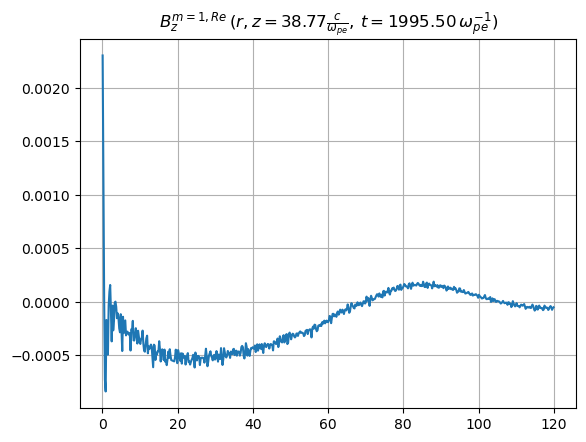

In [13]:
# Visualize Bz, m = 1 Real for an axial slice. This is what we will interpolate onto a cartesian grid

Bz_slice = data_dict['b1'][(1, 're')][1:, len(z_grid) // 6]

plt.plot(r_grid[1:], Bz_slice)
plt.title(r'$B_z^{m=1, Re} \, (r, z = $' + f"{z_grid[len(z_grid) // 6]:.2f}" + r'$\frac{c}{\omega_{pe}}, \, t = $' + f"{t_sim:.2f}" + r'$\, \omega_{pe}^{-1})$')
plt.grid(True)

### Interpolate onto a cartesian grid

In [14]:
def cartesian_rec(Br_rec, Bp_rec, Bz_rec, z_ind, phi):
    # converts cylindrical reconstructed components to cartesian for a z slice
    Bx_rec_slice = Br_rec[z_ind] * np.cos(phi) - Bp_rec[z_ind] * np.sin(phi)
    By_rec_slice = Br_rec[z_ind] * np.sin(phi) + Bp_rec[z_ind] * np.cos(phi)
    Bz_rec_slice = Bz_rec[z_ind]

    return Bx_rec_slice, By_rec_slice, Bz_rec_slice

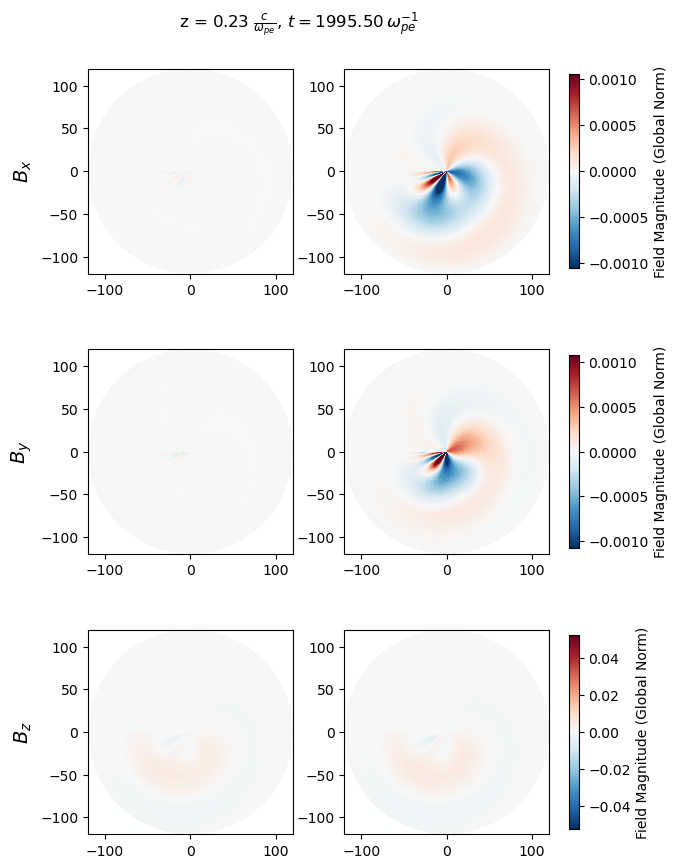

In [22]:
# Your code here
z_slice = 1
# fix z,r,phi to 1,2,3
Bz_m0 = data_dict['b1'][(0, 're')][1:,:]
Br_m0 = data_dict['b2'][(0, 're')][1:,:]
Bphi_m0 = data_dict['b3'][(0, 're')][1:,:]

phi_grid = gen_phi(nphi=1000)

X_rec, Y_rec = get_rec_cartesian_domain(r_grid, phi_grid)
M=1
# Bx_rec_slice, By_rec_slice, Bz_rec_slice = cartesian_rec(Br_m0.T, Bphi_m0.T, Bz_m0.T, z_slice, phi_grid)
# Bz_m0.shape

fig, axes = plt.subplots(3, M+1, figsize=(3*(M+1), 9))

Bx = Br_m0 * np.cos(phi_grid) - Bphi_m0 * np.sin(phi_grid)
By = Br_m0 * np.sin(phi_grid) + Bphi_m0 * np.cos(phi_grid)
Bz = Bz_m0
const_bound = 0.001
Bx_bound = np.max(np.abs(Bx))
By_bound = np.max(np.abs(By))
Bz_bound = np.max(np.abs(Bz))

Bx_color_norm = colors.Normalize(vmin=-Bx_bound, vmax=Bx_bound)
By_color_norm = colors.Normalize(vmin=-By_bound, vmax=By_bound)
Bz_color_norm = colors.Normalize(vmin=-Bz_bound, vmax=Bz_bound)
# Bx_color_norm = colors.Normalize(vmin=-const_bound, vmax=const_bound)
# By_color_norm = colors.Normalize(vmin=-const_bound, vmax=const_bound)
# Bz_color_norm = colors.Normalize(vmin=-const_bound, vmax=const_bound)

axes[0,0].pcolormesh(X_rec, Y_rec, Bx[:,1:].T, cmap='RdBu_r', norm=Bx_color_norm)
axes[1,0].pcolormesh(X_rec, Y_rec, By[:,1:].T, cmap='RdBu_r', norm=By_color_norm)
axes[2,0].pcolormesh(X_rec, Y_rec, Bz[:,1:].T, cmap='RdBu_r', norm=Bz_color_norm)

for m in range(1, M+1):
    cos_term = np.cos(m * phi_grid)
    sin_term = np.sin(m * phi_grid)
    
    Bz_m_re = data_dict['b1'][(m, 're')][1:,:]
    Br_m_re = data_dict['b2'][(m, 're')][1:,:]
    Bp_m_re = data_dict['b3'][(m, 're')][1:,:]
    
    Bz_m_im = data_dict['b1'][(m, 'im')][1:,:]
    Br_m_im = data_dict['b2'][(m, 'im')][1:,:]
    Bp_m_im = data_dict['b3'][(m, 'im')][1:,:]

    Bx += Br_m_re * cos_term - Br_m_im * sin_term
    By += Bp_m_re * cos_term - Bp_m_im * sin_term
    Bz += Bz_m_re * cos_term - Bz_m_im * sin_term

    pcm_Bx = axes[0,m].pcolormesh(X_rec, Y_rec, Bx[:,1:].T, cmap='RdBu_r', norm=Bx_color_norm)
    pcm_By = axes[1,m].pcolormesh(X_rec, Y_rec, By[:,1:].T, cmap='RdBu_r', norm=By_color_norm)
    pcm_Bz = axes[2,m].pcolormesh(X_rec, Y_rec, Bz[:,1:].T, cmap='RdBu_r', norm=Bz_color_norm)


for i, row in enumerate(axes):
    for j, col in enumerate(row):
        axes[i,j].set_aspect('equal')

axes[0,0].set_ylabel(r'$B_x$', fontsize=14)
axes[1,0].set_ylabel(r'$B_y$', fontsize=14)
axes[2,0].set_ylabel(r'$B_z$', fontsize=14)


fig.suptitle(r'z = ' + f"{z_grid[z_slice]:.2f}" + r' $\frac{c}{\omega_{pe}}, \, t = $' + f"{t_sim:.2f}" + r'$\, \omega_{pe}^{-1}$')
fig.tight_layout()

fig.colorbar(pcm_Bx, ax=axes[0,:], orientation='vertical', fraction=0.03, pad=0.04, shrink=0.8, label='Field Magnitude (Global Norm)')
fig.colorbar(pcm_By, ax=axes[1,:], orientation='vertical', fraction=0.03, pad=0.04, shrink=0.8, label='Field Magnitude (Global Norm)')
fig.colorbar(pcm_Bz, ax=axes[2,:], orientation='vertical', fraction=0.03, pad=0.04, shrink=0.8, label='Field Magnitude (Global Norm)')

# Mine went something like:

# Convert polar grid to cartesian grid

# Load in m = 0 Real mode for all 3 components of a given vector field
# Interpolate 0 mode onto cartesian grid into array that will be summed into across modes (i.e. Bz, Br, Bphi)

# in loop over mode number:

    # Load in real and imaginary mode
    # Compute sin and cos of phi array
    # Interpolate real and imaginary modes onto Cartesian grid
    # Accumulate sum for each vector component like F += F_real * cos(angles) - F_imaginary * sin(angles) --> minus sign is convention used in OSIRIS Quasi-3d algo


# Convert final Fz, Fr, Fphi arrays to Fx, Fy

In [ ]:
# Your code here
z_slice = 1
# fix z,r,phi to 1,2,3
Bz_m0 = data_dict['b1'][(0, 're')][1:,:]
Br_m0 = data_dict['b2'][(0, 're')][1:,:]
Bphi_m0 = data_dict['b3'][(0, 're')][1:,:]

phi_grid = gen_phi(nphi=1000)

X_rec, Y_rec = get_rec_cartesian_domain(r_grid, phi_grid)
M=1
# Bx_rec_slice, By_rec_slice, Bz_rec_slice = cartesian_rec(Br_m0.T, Bphi_m0.T, Bz_m0.T, z_slice, phi_grid)
# Bz_m0.shape

fig, axes = plt.subplots(3, M+1, figsize=(3*(M+1), 9))

Bx = Br_m0 * np.cos(phi_grid) - Bphi_m0 * np.sin(phi_grid)
By = Br_m0 * np.sin(phi_grid) + Bphi_m0 * np.cos(phi_grid)
Bz = Bz_m0
const_bound = 0.001
Bx_bound = np.max(np.abs(Bx))
By_bound = np.max(np.abs(By))
Bz_bound = np.max(np.abs(Bz))

Bx_color_norm = colors.Normalize(vmin=-Bx_bound, vmax=Bx_bound)
By_color_norm = colors.Normalize(vmin=-By_bound, vmax=By_bound)
Bz_color_norm = colors.Normalize(vmin=-Bz_bound, vmax=Bz_bound)
# Bx_color_norm = colors.Normalize(vmin=-const_bound, vmax=const_bound)
# By_color_norm = colors.Normalize(vmin=-const_bound, vmax=const_bound)
# Bz_color_norm = colors.Normalize(vmin=-const_bound, vmax=const_bound)

axes[0,0].pcolormesh(X_rec, Y_rec, Bx[:,1:].T, cmap='RdBu_r', norm=Bx_color_norm)
axes[1,0].pcolormesh(X_rec, Y_rec, By[:,1:].T, cmap='RdBu_r', norm=By_color_norm)
axes[2,0].pcolormesh(X_rec, Y_rec, Bz[:,1:].T, cmap='RdBu_r', norm=Bz_color_norm)

for m in range(1, M+1):
    cos_term = np.cos(m * phi_grid)
    sin_term = np.sin(m * phi_grid)
    
    Bz_m_re = data_dict['b1'][(m, 're')][1:,:]
    Br_m_re = data_dict['b2'][(m, 're')][1:,:]
    Bp_m_re = data_dict['b3'][(m, 're')][1:,:]
    
    Bz_m_im = data_dict['b1'][(m, 'im')][1:,:]
    Br_m_im = data_dict['b2'][(m, 'im')][1:,:]
    Bp_m_im = data_dict['b3'][(m, 'im')][1:,:]

    Bx += Br_m_re * cos_term - Br_m_im * sin_term
    By += Bp_m_re * cos_term - Bp_m_im * sin_term
    Bz += Bz_m_re * cos_term - Bz_m_im * sin_term

    pcm_Bx = axes[0,m].pcolormesh(X_rec, Y_rec, Bx[:,1:].T, cmap='RdBu_r', norm=Bx_color_norm)
    pcm_By = axes[1,m].pcolormesh(X_rec, Y_rec, By[:,1:].T, cmap='RdBu_r', norm=By_color_norm)
    pcm_Bz = axes[2,m].pcolormesh(X_rec, Y_rec, Bz[:,1:].T, cmap='RdBu_r', norm=Bz_color_norm)


for i, row in enumerate(axes):
    for j, col in enumerate(row):
        axes[i,j].set_aspect('equal')

axes[0,0].set_ylabel(r'$B_x$', fontsize=14)
axes[1,0].set_ylabel(r'$B_y$', fontsize=14)
axes[2,0].set_ylabel(r'$B_z$', fontsize=14)


fig.suptitle(r'z = ' + f"{z_grid[z_slice]:.2f}" + r' $\frac{c}{\omega_{pe}}, \, t = $' + f"{t_sim:.2f}" + r'$\, \omega_{pe}^{-1}$')
fig.tight_layout()

fig.colorbar(pcm_Bx, ax=axes[0,:], orientation='vertical', fraction=0.03, pad=0.04, shrink=0.8, label='Field Magnitude (Global Norm)')
fig.colorbar(pcm_By, ax=axes[1,:], orientation='vertical', fraction=0.03, pad=0.04, shrink=0.8, label='Field Magnitude (Global Norm)')
fig.colorbar(pcm_Bz, ax=axes[2,:], orientation='vertical', fraction=0.03, pad=0.04, shrink=0.8, label='Field Magnitude (Global Norm)')

def update(frame):
    # new data
    Bx = Bvec[frame][i]["DATA_X"]
    By = Bvec[frame][i]["DATA_Y"]
    Bz = Bvec[frame][i]["DATA_Z"]

    pcm.set_array(Bz.ravel())
    pcm.set_norm(Bz_norm_anim)

    strm = ax.streamplot(X, Y, Bx, By, color="black", density=0.8)

fig.colorbar(pcm, label=r'$B_z$ (slice norm)', norm=Bz_norm_anim)
anim = FuncAnimation(fig, update, frames=range(len(times)), interval=50, blit=False)
anim.save(f'Bvec_z{i}.mp4')

### Visualize cartesian projection

In [ ]:
# your code here